# Apartment Data Cleaning Workflow
This notebook cleans apartment listing data through profiling, missing-value handling, outlier treatment, and final export.

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(pd.__version__)

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) 

print("Libraries imported successfully!")

2.3.0
Libraries imported successfully!


## Load Dataset and Perform Initial Inspection
Read the apartment dataset and review its shape, schema, and sample rows to confirm basic integrity.

In [200]:
df = pd.read_csv('../../data/apartment/satilir_properties_apartment.csv')
print("Data loaded successfully!")

print("Dataset shape:", df.shape)

print("Number of observations:", df.shape[0])

print("Number of features:", df.shape[1])

Data loaded successfully!
Dataset shape: (4987, 24)
Number of observations: 4987
Number of features: 24


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4987 entries, 0 to 4986
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     4987 non-null   int64  
 1   rooms                     4986 non-null   float64
 2   area_m2                   4987 non-null   float64
 3   floor                     4986 non-null   float64
 4   has_document              4987 non-null   object 
 5   address                   4987 non-null   object 
 6   avtodayanacaq             4987 non-null   object 
 7   balkon                    4987 non-null   object 
 8   duzelme                   4987 non-null   object 
 9   esyali                    4987 non-null   object 
 10  hovuz                     4987 non-null   object 
 11  internet                  4987 non-null   object 
 12  isiq                      4987 non-null   object 
 13  kabel_tv                  4987 non-null   object 
 14  kombi   

In [202]:
df.head()

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
0,200000,3.0,65.0,5.0,No,"Bakı, Nərimanov, metro 28 May",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes
1,800000,4.0,197.0,9.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
2,210000,2.0,54.0,12.0,No,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,149000,4.0,100.0,2.0,Yes,"Bakı, Binəqədi, Biləcəri qəs.",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes
4,45000,1.0,44.0,1.0,Yes,Xırdalan,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


## Detect and Remove Duplicate Rows
Measure duplicate records, inspect them, remove exact duplicates, and compare dataset size before versus after deduplication.

In [203]:
print(df.duplicated().sum())

200


In [204]:
dup_rows = df[df.duplicated(keep=False)]  
dup_rows.sort_index()  

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
36,12000,2.0,59.39,6.0,Yes,"Bakı, Abşeron, Qobu",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
56,115000,3.0,75.00,2.0,Yes,"Bakı, Abşeron, Masazır",Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes
87,10000,2.0,50.00,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes
88,10000,2.0,50.00,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes
89,10000,2.0,50.00,1.0,Yes,"Bakı, Abşeron, Masazır",Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4874,65000,2.0,38.00,5.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4884,130000,2.0,55.00,2.0,No,"Bakı, Xətai, Əhmədli, metro Həzi Aslanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4904,368000,3.0,100.00,13.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
4934,65000,2.0,65.00,12.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon, metro Dərnəgül",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [205]:
df_2 = df.drop_duplicates(keep="first").reset_index(drop=True)

In [206]:
print("Previous dataset shape:", df.shape)
print("Duplicates removed. New dataset shape:", df_2.shape)
print("Number of duplicates removed:", df.shape[0] - df_2.shape[0])

Previous dataset shape: (4987, 24)
Duplicates removed. New dataset shape: (4787, 24)
Number of duplicates removed: 200


## Profile Feature Types
Separate columns into numeric and categorical groups to guide cleaning strategy and later analysis.

In [207]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numerical columns:", len(num_cols))
print("Numerical columns:", num_cols)

Number of numerical columns: 4
Numerical columns: ['price', 'rooms', 'area_m2', 'floor']


In [208]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(cat_cols))
print("Categorical columns:", cat_cols)

Number of categorical columns: 20
Categorical columns: ['has_document', 'address', 'avtodayanacaq', 'balkon', 'duzelme', 'esyali', 'hovuz', 'internet', 'isiq', 'kabel_tv', 'kombi', 'kondisioner', 'lift', 'merkezi_qizdirici_sistem', 'metbex_mebeli', 'pvc_pencere', 'qaz', 'su', 'telefon', 'temirli']


## Analyze Missing Values and Investigate Problematic Records
Create a reusable missing-value summary, clone the dataset for cleaning, and inspect rows that need targeted fixes.

In [209]:
def df_missing_values_summary(df):
    mis_values = df.isnull().sum()
    mis_percent = (mis_values / len(df)) * 100

    df_mis = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": mis_values,
        "Percentage": mis_percent
    })

    df_mis = df_mis[df_mis["Missing Values"] > 0].sort_values(by="Percentage", ascending=False).reset_index(drop=True)
    return df_mis

In [210]:
df_mis = df_missing_values_summary(df)
print("Missing values summary:")
print("Number of columns with missing values:", df_mis.shape[0])
df_mis

Missing values summary:
Number of columns with missing values: 2


,Column,Missing Values,Percentage
0,rooms,1,0.020052
1,floor,1,0.020052


In [211]:
df_clean = df.copy()

In [212]:
df_clean.loc[df_clean["rooms"].isnull()]

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
822,35000,NaN,16.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,Yes


In [213]:
df_clean.query(" 10 <= area_m2 <= 20")

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
617,37000,1.0,20.0,21.0,Yes,"Bakı, Binəqədi, 8-ci mikrorayon, metro Azadlıq",No,No,No,Yes,No,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes
822,35000,NaN,16.0,NaN,No,"Bakı, Qaradağ, Lökbatan qəs.",No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,No,Yes,No,Yes
2747,88000,1.0,20.0,2.0,Yes,"Bakı, Nəsimi",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes
2904,25000,1.0,20.0,2.0,Yes,"Sumqayıt, 12-ci mikrorayon",No,Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,Yes,Yes,Yes,Yes,No


## Apply Targeted Data Fixes and Recheck Missingness
Patch known anomalies in rooms and floor, then recompute missing-value statistics to validate improvements.

In [214]:
df_clean.loc[(df_clean["area_m2"] == 16) & (df_clean["rooms"].isnull()), "rooms"] = 1
df_clean.loc[(df_clean["area_m2"] == 16) & (df_clean["floor"].isnull()), "floor"] = 1

In [215]:
df_mis_2 = df_missing_values_summary(df_clean)
print("Missing values summary:")
print("Number of columns with missing values:", df_mis_2.shape[0])
df_mis_2

Missing values summary:
Number of columns with missing values: 0


,Column,Missing Values,Percentage


## Explore Numeric Distributions and Handle Major Price Outlier
Visualize key numeric features, inspect price spread, remove the extreme price value, and compare distributions.

In [216]:
def plot_numeric_distributions(df, numeric_cols):
    key_numeric_features = [col for col in numeric_cols if col in df.columns]

    fig, axes = plt.subplots(len(key_numeric_features), 1, figsize=(5, 2*len(key_numeric_features)))

    if len(key_numeric_features) == 1:
        axes = [axes]
    for i, col in enumerate(key_numeric_features):
        axes[i].boxplot(df[col].dropna(), vert=False)
        axes[i].set_ylabel(col)
        axes[i].set_title(f"Box Plot of {col}")
    plt.tight_layout()
    plt.show()

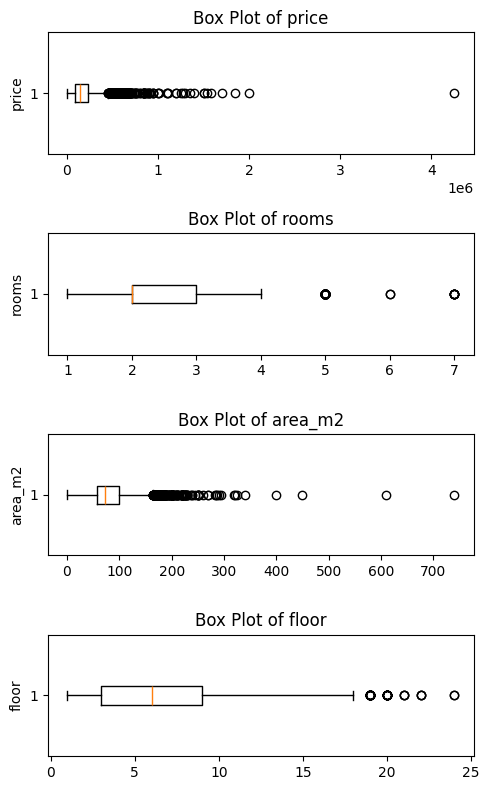

In [217]:
key_numeric_features = ['price', 'rooms', 'area_m2', 'floor']
plot_numeric_distributions(df_clean, key_numeric_features)

In [218]:
df_clean['price'].describe()

count    4.987000e+03
mean     1.831034e+05
std      1.621614e+05
min      7.300000e+03
25%      8.800000e+04
50%      1.490000e+05
75%      2.330000e+05
max      4.250000e+06
Name: price, dtype: float64

In [219]:
df_clean.drop(df_clean[df_clean['price'] == 4250000].index, inplace=True)
df_clean['price'].describe()

count    4.986000e+03
mean     1.822877e+05
std      1.516016e+05
min      7.300000e+03
25%      8.800000e+04
50%      1.490000e+05
75%      2.327500e+05
max      2.000000e+06
Name: price, dtype: float64

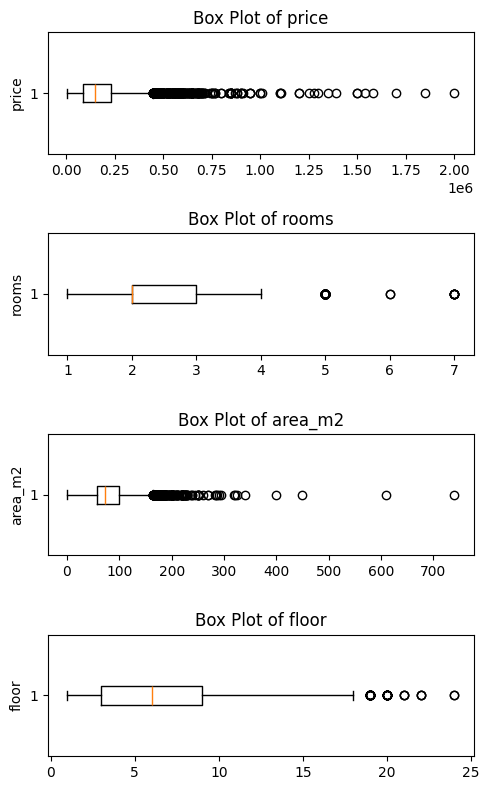

In [220]:
plot_numeric_distributions(df_clean, key_numeric_features)

In [221]:
def IQR_finding_outliers(df,column):
    Q1 = np.percentile(df[column].dropna(),25)
    Q3 = np.percentile(df[column].dropna(),75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound ,upper_bound

for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers found: {outliers.shape[0]}\n")
    

Column: price
Lower Bound: -129125.0, Upper Bound: 449875.0
Number of outliers found: 252

Column: rooms
Lower Bound: 0.5, Upper Bound: 4.5
Number of outliers found: 92

Column: area_m2
Lower Bound: -7.5, Upper Bound: 164.5
Number of outliers found: 187

Column: floor
Lower Bound: -6.0, Upper Bound: 18.0
Number of outliers found: 50



## Detect and Filter Outliers with the IQR Method
Estimate per-feature outlier bounds, remove outliers, and compare dataset size before and after filtering.

In [222]:
for col in key_numeric_features:
    outliers, lower_bound, upper_bound = IQR_finding_outliers(df_clean, col)
    df_clean_2 = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


In [223]:
print("Before outlier removal:", df_clean.shape)
print("After outlier removal:", df_clean_2.shape)
print("Outliers removed:", df_clean.shape[0] - df_clean_2.shape[0])

Before outlier removal: (4986, 24)
After outlier removal: (4936, 24)
Outliers removed: 50


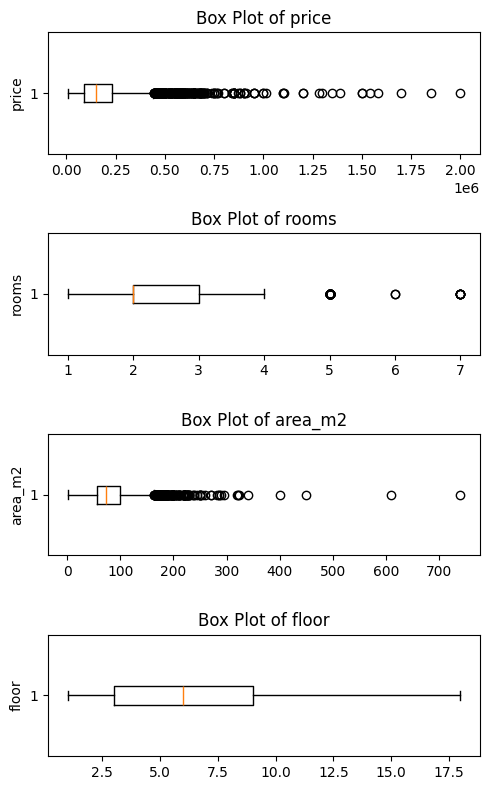

In [224]:
plot_numeric_distributions(df_clean_2, key_numeric_features)

## Correlation Heatmap
Visualize the relationships between numeric features in the cleaned apartment dataset to spot linear associations.

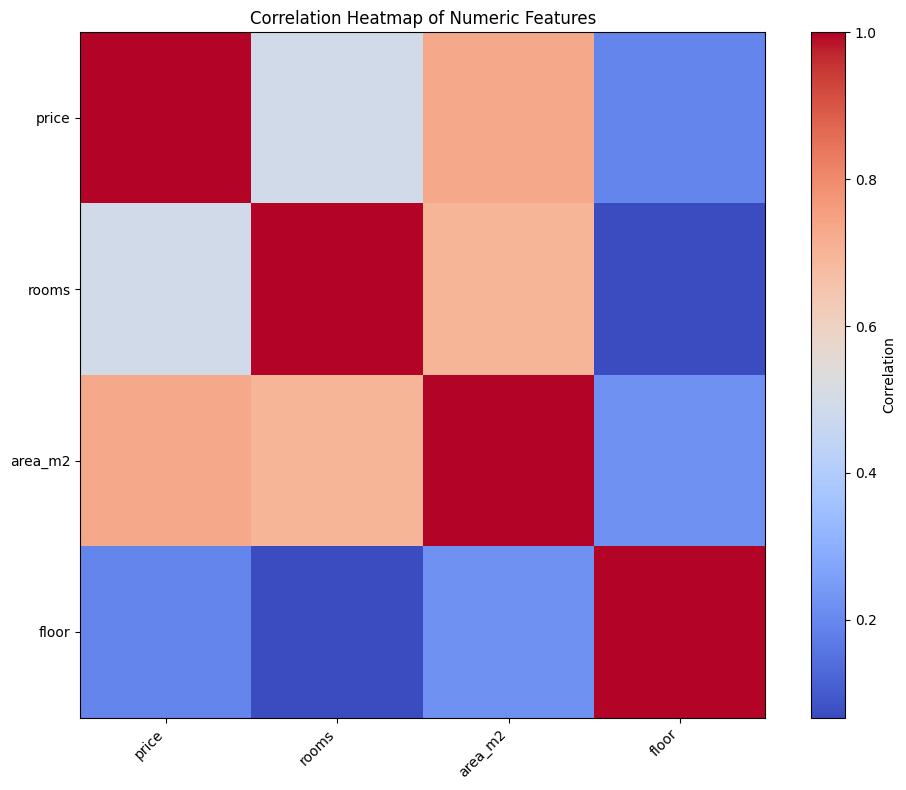

In [225]:
numeric_df = df_clean_2.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Scatter Plots Before and After Outlier Removal
Compare the relationship between price and the main numeric features before and after outlier filtering.

Before outlier removal: (4987, 24)
After outlier removal: (4936, 24)


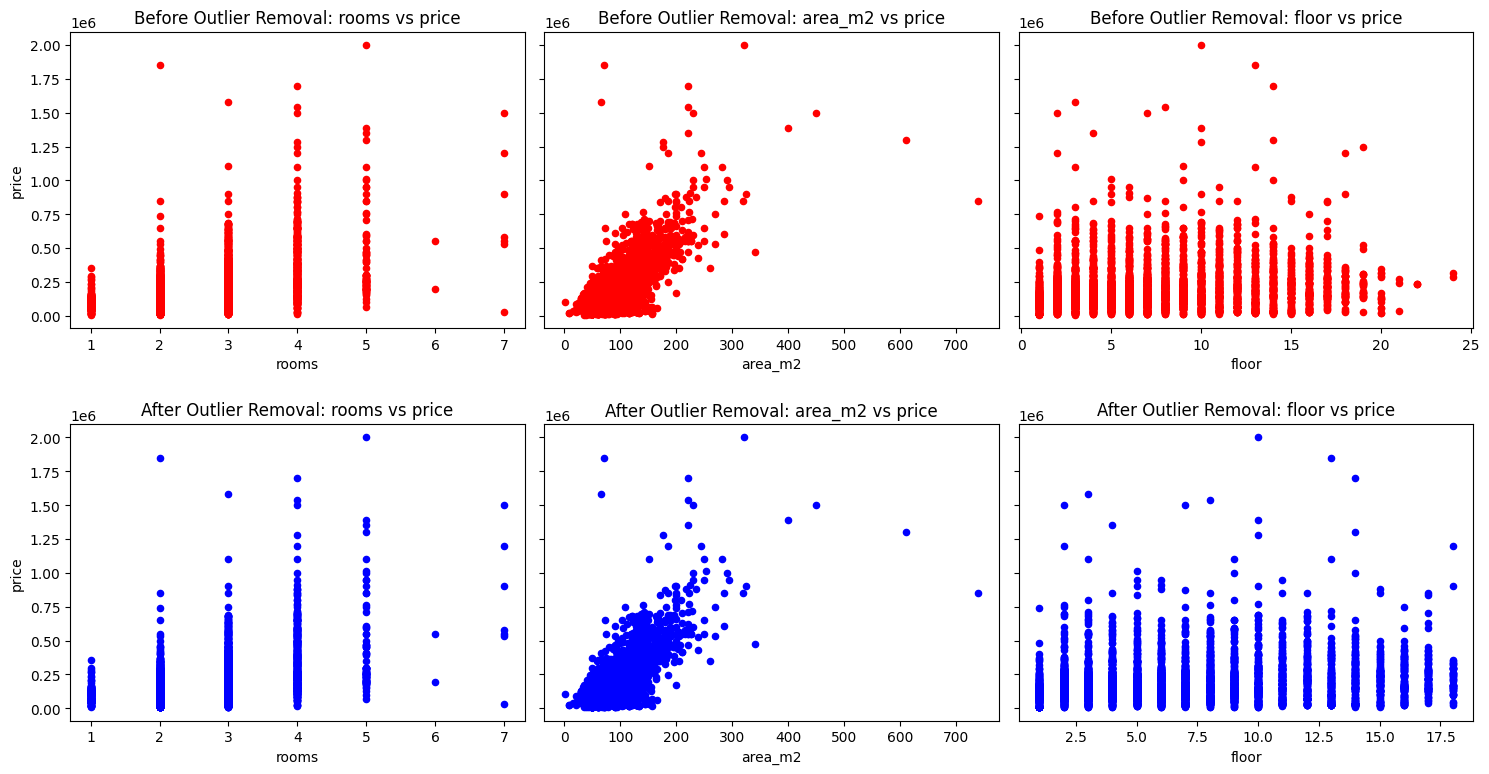

In [226]:
feature_cols = [c for c in key_numeric_features if c != 'price']

if not feature_cols:
    feature_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns if c != 'price'][:5]

fig, axes = plt.subplots(nrows=2, ncols=len(feature_cols), figsize=(5 * len(feature_cols), 8))
axes = np.ravel(axes)

for i, c in enumerate(feature_cols):
    df_clean.plot.scatter(ax=axes[i], x=c, y='price', sharey=True, colorbar=False, c='r')
    axes[i].set_title(f'Before Outlier Removal: {c} vs price')

print('Before outlier removal:', df.shape)

after_offset = len(feature_cols)
for i, c in enumerate(feature_cols, start=after_offset):
    df_clean_2.plot.scatter(ax=axes[i], x=c, y='price', sharey=True, colorbar=False, c='b')
    axes[i].set_title(f'After Outlier Removal: {c} vs price')

print('After outlier removal:', df_clean_2.shape)
plt.tight_layout()
plt.show()

In [227]:
df_clean_2[df_clean_2['price'] >= 1750000]

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli
2300,2000000,5.0,321.0,10.0,Yes,"Bakı, Səbail, Bayıl qəs.",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes
2473,1850000,2.0,70.0,13.0,Yes,"Bakı, Yasamal",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes


In [228]:
df_clean_2 = df_clean_2[df_clean_2["price"] != 1850000].reset_index(drop=True)

print("Rows with price 1850000 removed.")
print("New cleaned dataset shape:", df_clean_2.shape)

Rows with price 1850000 removed.
New cleaned dataset shape: (4935, 24)


In [229]:
df_clean_2 = df_clean_2[df_clean_2["area_m2"] <= 300].reset_index(drop=True)
print("Rows with area_m2 > 300 removed.")
print("New cleaned dataset shape:", df_clean_2.shape)

Rows with area_m2 > 300 removed.
New cleaned dataset shape: (4927, 24)


In [230]:
# Add price per square meter feature and inspect outliers

df_clean_2["price_per_m2"] = df_clean_2["price"] / df_clean_2["area_m2"].replace(0, np.nan)

print("price_per_m2 summary:")
print(df_clean_2["price_per_m2"].describe())

q1 = df_clean_2["price_per_m2"].quantile(0.25)
q3 = df_clean_2["price_per_m2"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_per_m2_outliers = df_clean_2[(df_clean_2["price_per_m2"] < lower_bound) | (df_clean_2["price_per_m2"] > upper_bound)]

print(f"IQR lower bound: {lower_bound:.2f}")
print(f"IQR upper bound: {upper_bound:.2f}")
print("Number of price_per_m2 outliers:", price_per_m2_outliers.shape[0])

price_per_m2_outliers[["price", "area_m2", "price_per_m2"]].head()

price_per_m2 summary:
count      4927.000000
mean       2159.536626
std        1805.806241
min          89.743590
25%        1429.197995
50%        2112.500000
75%        2800.000000
max      103000.000000
Name: price_per_m2, dtype: float64
IQR lower bound: -627.01
IQR upper bound: 4856.20
Number of price_per_m2 outliers: 55


,price,area_m2,price_per_m2
526,680000,130.0,5230.769231
569,170000,35.0,4857.142857
667,259000,51.0,5078.431373
768,258000,51.0,5058.823529
769,364000,65.0,5600.000000


In [231]:
if "price_per_m2" not in df_clean_2.columns:
    df_clean_2["price_per_m2"] = df_clean_2["price"] / df_clean_2["area_m2"].replace(0, np.nan)

before_shape = df_clean_2.shape
df_clean_2 = df_clean_2[df_clean_2["price_per_m2"] <= 8000].reset_index(drop=True)
after_shape = df_clean_2.shape

print("Rows with price_per_m2 > 8000 removed.")
print("Before:", before_shape)
print("After:", after_shape)
print("Removed:", before_shape[0] - after_shape[0])

Rows with price_per_m2 > 8000 removed.
Before: (4927, 25)
After: (4924, 25)
Removed: 3


In [232]:
price_per_m2_outliers

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2
526,680000,3.0,130.0,12.0,Yes,"Bakı, Xətai, Ağ şəhər, metro Xətai",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5230.769231
569,170000,2.0,35.0,4.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4857.142857
667,259000,2.0,51.0,15.0,Yes,"Bakı, Nəsimi, metro 28 May",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,5078.431373
768,258000,2.0,51.0,15.0,Yes,"Bakı, Nəsimi, metro 28 May",Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,5058.823529
769,364000,2.0,65.0,16.0,Yes,"Bakı, Xətai, Ağ şəhər, metro Xətai",Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5600.000000
946,445000,3.0,90.0,5.0,Yes,"Bakı, Səbail, metro Sahil",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,4944.444444
1022,595000,3.0,105.0,5.0,Yes,"Bakı, Nəsimi, metro Nizami",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5666.666667
1076,530000,2.0,90.0,4.0,No,"Bakı, Xətai, Ağ şəhər, metro Xətai",Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,5888.888889
1262,450000,2.0,80.0,13.0,Yes,"Bakı, Nəsimi, metro 28 May",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,5625.000000
1340,245000,2.0,50.0,12.0,No,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4900.000000


In [233]:
# Remove only "Ag seher" entries from price_per_m2_outliers
preferred_cols = ["location", "address", "district", "rayon", "settlement"]
text_cols = price_per_m2_outliers.select_dtypes(include=["object"]).columns.tolist()
location_col = next((c for c in preferred_cols if c in text_cols), None)

if location_col is None:
    print("No suitable location-like text column found in price_per_m2_outliers.")
else:
    pattern = r"(ağ|ag)\s*(şəhər|seher)"
    before = price_per_m2_outliers.shape[0]
    price_per_m2_outliers = price_per_m2_outliers[
        ~price_per_m2_outliers[location_col].fillna("").str.lower().str.contains(pattern, regex=True)
    ]
    after = price_per_m2_outliers.shape[0]

    print(f"Column used: {location_col}")
    print(f"Removed from price_per_m2_outliers: {before - after}")
    print(f"Remaining outliers: {after}")

price_per_m2_outliers.head()

Column used: address
Removed from price_per_m2_outliers: 25
Remaining outliers: 30


C:\Users\user\AppData\Local\Temp\ipykernel_11632\306215203.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~price_per_m2_outliers[location_col].fillna("").str.lower().str.contains(pattern, regex=True)


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2
569,170000,2.0,35.0,4.0,Yes,"Bakı, Nərimanov, metro Gənclik",Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4857.142857
667,259000,2.0,51.0,15.0,Yes,"Bakı, Nəsimi, metro 28 May",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,5078.431373
768,258000,2.0,51.0,15.0,Yes,"Bakı, Nəsimi, metro 28 May",Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,5058.823529
946,445000,3.0,90.0,5.0,Yes,"Bakı, Səbail, metro Sahil",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,No,Yes,4944.444444
1022,595000,3.0,105.0,5.0,Yes,"Bakı, Nəsimi, metro Nizami",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,5666.666667


In [234]:
houses_6_7_rooms = df_clean_2[df_clean_2["rooms"].isin([6, 7])]
print("Number of houses with 6 or 7 rooms:", houses_6_7_rooms.shape[0])
houses_6_7_rooms

Number of houses with 6 or 7 rooms: 7


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2
243,195000,6.0,150.0,1.0,Yes,"Bakı, Xətai, Əhmədli, metro Əhmədli",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1300.000000
917,530000,7.0,270.0,14.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,1962.962963
1629,580000,7.0,187.0,4.0,Yes,"Bakı, Səbail, Badamdar qəs., metro Elmlər akad...",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,Yes,Yes,No,Yes,3101.604278
2104,550000,6.0,250.0,12.0,Yes,"Bakı, Nəsimi",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2200.000000
2243,31000,7.0,56.0,7.0,Yes,Xırdalan,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,553.571429
2461,1200000,7.0,245.0,2.0,Yes,"Bakı, Səbail, metro Sahil",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,4897.959184
2575,550000,7.0,210.0,5.0,Yes,"Bakı, Səbail, Bayıl qəs., metro İçərişəhər",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,2619.047619


In [235]:
# Delete rows with specific price_per_m2 values
if "price_per_m2" not in df_clean_2.columns:
    df_clean_2["price_per_m2"] = df_clean_2["price"] / df_clean_2["area_m2"].replace(0, np.nan)

target_values = np.array([4897.959184, 553.571429])
mask_to_remove = np.isclose(df_clean_2["price_per_m2"].to_numpy()[:, None], target_values[None, :], atol=1e-6).any(axis=1)

before_rows = df_clean_2.shape[0]
df_clean_2 = df_clean_2.loc[~mask_to_remove].reset_index(drop=True)
after_rows = df_clean_2.shape[0]

print("Removed rows with target price_per_m2 values:", before_rows - after_rows)
print("New cleaned dataset shape:", df_clean_2.shape)

Removed rows with target price_per_m2 values: 2
New cleaned dataset shape: (4922, 25)


In [236]:
houses_6_7_rooms = df_clean_2[df_clean_2["rooms"].isin([6, 7])]
print("Number of houses with 6 or 7 rooms:", houses_6_7_rooms.shape[0])
houses_6_7_rooms

Number of houses with 6 or 7 rooms: 5


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2
243,195000,6.0,150.0,1.0,Yes,"Bakı, Xətai, Əhmədli, metro Əhmədli",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1300.000000
917,530000,7.0,270.0,14.0,Yes,"Bakı, Nərimanov, metro Nəriman Nərimanov",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,1962.962963
1629,580000,7.0,187.0,4.0,Yes,"Bakı, Səbail, Badamdar qəs., metro Elmlər akad...",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,Yes,Yes,No,Yes,3101.604278
2104,550000,6.0,250.0,12.0,Yes,"Bakı, Nəsimi",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2200.000000
2573,550000,7.0,210.0,5.0,Yes,"Bakı, Səbail, Bayıl qəs., metro İçərişəhər",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,2619.047619


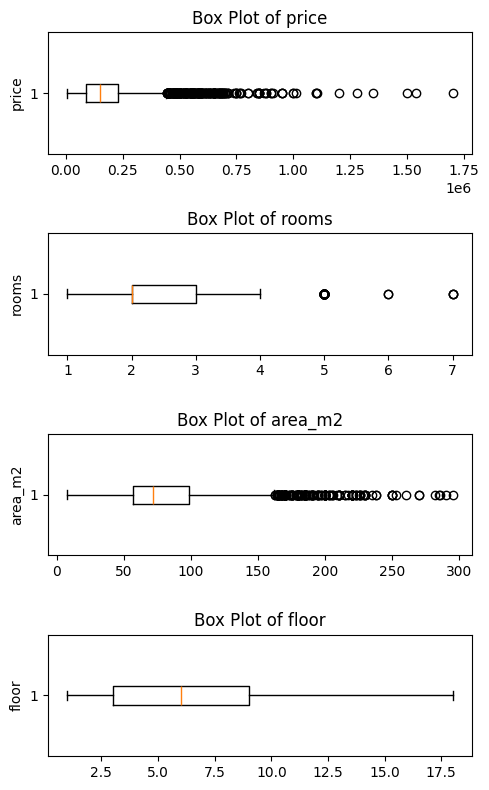

In [237]:
plot_numeric_distributions(df_clean_2, key_numeric_features)

In [238]:
houses_over_1_1m = df_clean_2[df_clean_2["price"] > 1_100_000]
print("Number of houses with price > 1.1M:", houses_over_1_1m.shape[0])
houses_over_1_1m

Number of houses with price > 1.1M: 7


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2
1376,1105000,3.0,152.0,9.0,Yes,"Bakı, Səbail, metro Sahil",Yes,Yes,No,No,No,Yes,Yes,No,Yes,No,Yes,No,No,Yes,Yes,Yes,No,No,7269.736842
1547,1350000,5.0,220.0,4.0,Yes,"Bakı, Xətai, Ağ şəhər, metro Xətai",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,6136.363636
1693,1540000,4.0,220.0,8.0,No,"Bakı, Xətai, Ağ şəhər, metro Xətai",Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,7000.000000
1711,1700000,4.0,220.0,14.0,No,"Bakı, Xətai, Ağ şəhər, metro Xətai",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,7727.272727
2276,1200000,4.0,185.0,18.0,No,"Bakı, Xətai, Ağ şəhər",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,6486.486486
2460,1280000,4.0,175.3,10.0,Yes,"Bakı, Nəsimi, metro 28 May",Yes,Yes,No,No,No,No,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,No,7301.768397
2995,1500000,4.0,230.0,7.0,Yes,"Bakı, Nəsimi, metro Nizami",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,6521.739130


In [239]:
# Divide rooms into groups and check correlation with price
room_labels = ["1-2", "3-4", "5-6", "7+"]
df_clean_2["rooms_group"] = pd.cut(
    df_clean_2["rooms"],
    bins=[0, 2, 4, 6, np.inf],
    labels=room_labels,
    include_lowest=True
)

group_price_stats = (
    df_clean_2.groupby("rooms_group", observed=False)["price"]
    .agg(count="count", mean_price="mean", median_price="median", std_price="std")
    .reset_index()
)
print("Price stats by room group:")
print(group_price_stats)

# Ordinal encoding for correlation
room_code_map = {"1-2": 1, "3-4": 2, "5-6": 3, "7+": 4}
df_clean_2["rooms_group_code"] = df_clean_2["rooms_group"].astype(str).map(room_code_map)

pearson_corr = df_clean_2[["rooms_group_code", "price"]].corr(method="pearson").iloc[0, 1]
spearman_corr = df_clean_2[["rooms_group_code", "price"]].corr(method="spearman").iloc[0, 1]

print(f"Pearson corr (rooms_group_code vs price): {pearson_corr:.4f}")
print(f"Spearman corr (rooms_group_code vs price): {spearman_corr:.4f}")

Price stats by room group:
  rooms_group  count     mean_price  median_price      std_price
0         1-2   2537  122500.176981      112000.0   75109.095375
1         3-4   2301  234505.155585      202000.0  160073.287089
2         5-6     81  379123.456790      265000.0  260875.934724
3          7+      3  553333.333333      550000.0   25166.114784
Pearson corr (rooms_group_code vs price): 0.4385
Spearman corr (rooms_group_code vs price): 0.4554


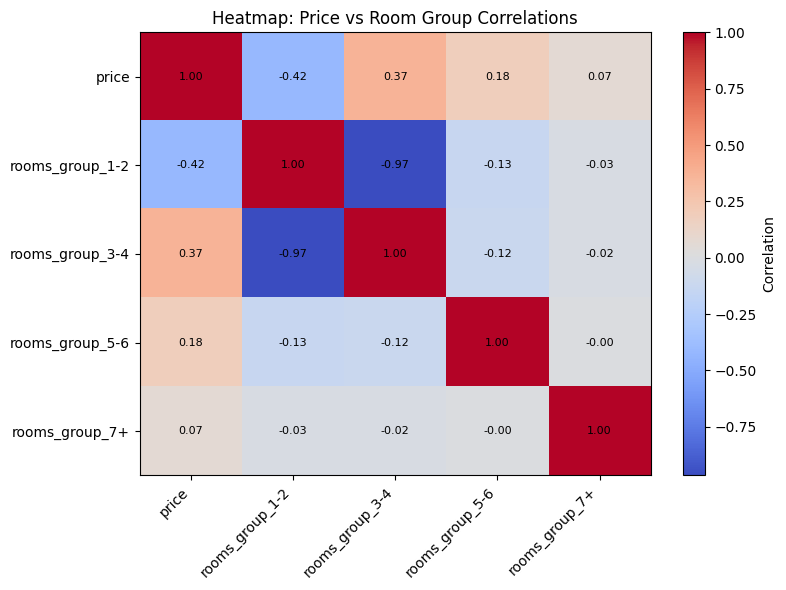

Correlation of each room group with price:
rooms_group_3-4    0.367126
rooms_group_5-6    0.183570
rooms_group_7+     0.065609
rooms_group_1-2   -0.416496
Name: price, dtype: float64


In [240]:
# Heatmap: correlation between room groups and price
if "rooms_group" not in df_clean_2.columns:
    df_clean_2["rooms_group"] = pd.cut(
        df_clean_2["rooms"],
        bins=[0, 2, 4, 6, np.inf],
        labels=["1-2", "3-4", "5-6", "7+"],
        include_lowest=True
    )

room_group_dummies = pd.get_dummies(df_clean_2["rooms_group"], prefix="rooms_group")
heatmap_df = pd.concat([df_clean_2[["price"]], room_group_dummies], axis=1)
corr_matrix = heatmap_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Heatmap: Price vs Room Group Correlations")

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

print("Correlation of each room group with price:")
print(corr_matrix.loc["price"].drop("price").sort_values(ascending=False))

In [241]:
# Skewness for every possible feature (numeric-convertible)
numeric_convertible = df_clean_2.apply(pd.to_numeric, errors="coerce")

valid_cols = [
    c for c in numeric_convertible.columns
    if numeric_convertible[c].notna().sum() >= 3 and numeric_convertible[c].nunique(dropna=True) > 2
]

skewness_df = pd.DataFrame({
    "feature": valid_cols,
    "skewness": [numeric_convertible[c].dropna().skew() for c in valid_cols],
    "non_null_count": [numeric_convertible[c].notna().sum() for c in valid_cols]
}).sort_values("skewness", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

print("Skewness summary (sorted by |skewness|):")
skewness_df

Skewness summary (sorted by |skewness|):


,feature,skewness,non_null_count
0,price,2.586180,4922
1,area_m2,1.575759,4922
2,rooms,0.743633,4922
3,floor,0.740954,4922
4,price_per_m2,0.450316,4922
5,rooms_group_code,0.372661,4922


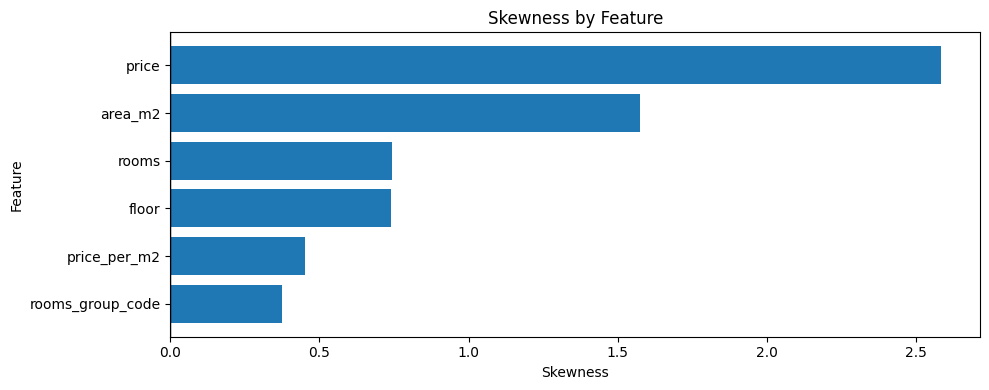

In [242]:
# Plot skewness for all valid features
if "skewness_df" not in globals() or skewness_df.empty:
    numeric_convertible = df_clean_2.apply(pd.to_numeric, errors="coerce")
    valid_cols = [
        c for c in numeric_convertible.columns
        if numeric_convertible[c].notna().sum() >= 3 and numeric_convertible[c].nunique(dropna=True) > 2
    ]
    skewness_df = pd.DataFrame({
        "feature": valid_cols,
        "skewness": [numeric_convertible[c].dropna().skew() for c in valid_cols],
        "non_null_count": [numeric_convertible[c].notna().sum() for c in valid_cols]
    }).sort_values("skewness", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

plot_df = skewness_df.sort_values("skewness")

plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
colors = ["#d62728" if v < 0 else "#1f77b4" for v in plot_df["skewness"]]
plt.barh(plot_df["feature"], plot_df["skewness"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Skewness by Feature")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Skewness comparison (observation only):
price original: 2.5862
price log1p   : -0.8453
-
area_m2 original: 1.5758
area_m2 sqrt    : 0.8976
area_m2 log1p   : 0.2754


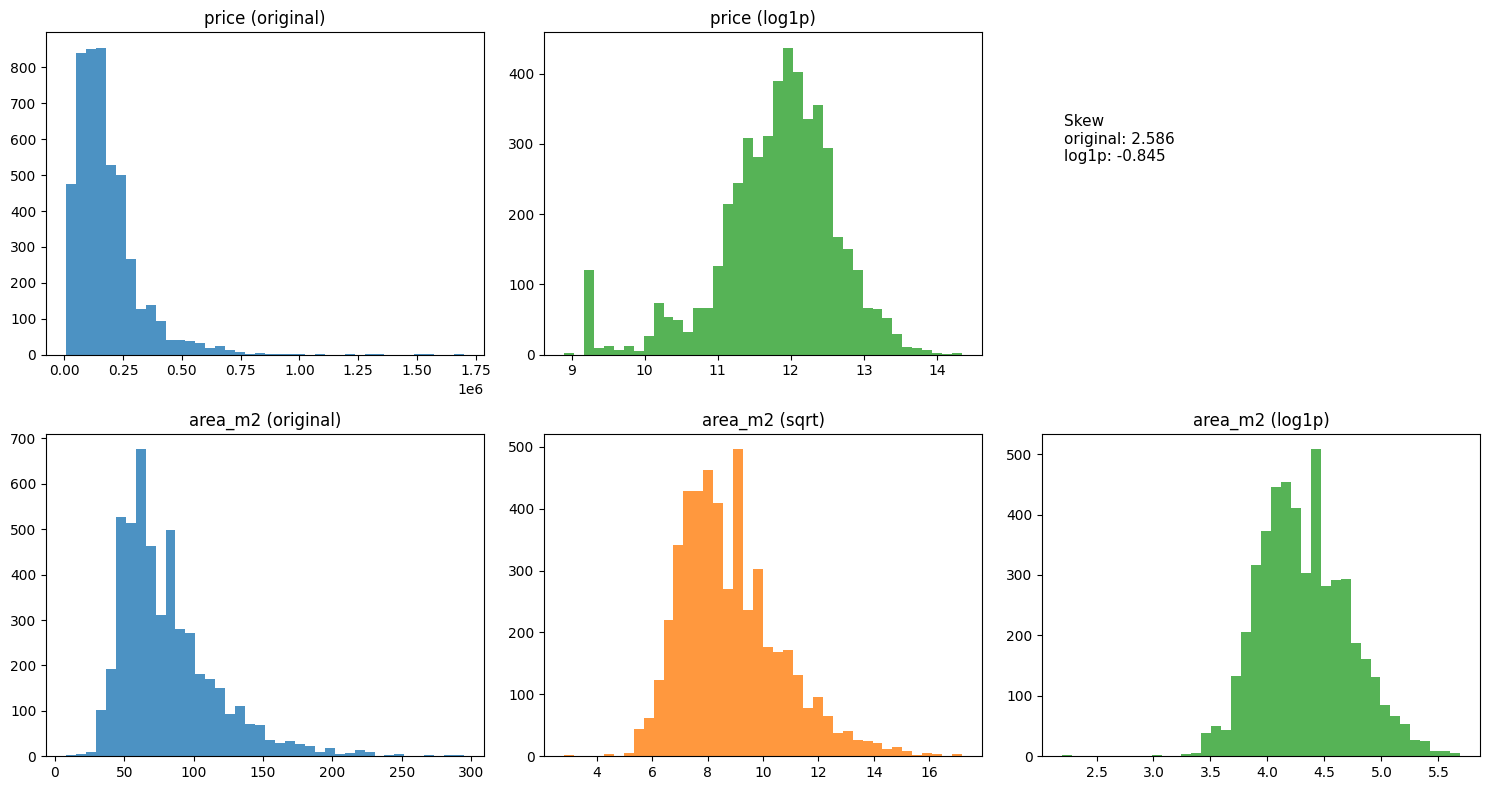

In [243]:
# Observe skewness fixes (without changing the dataset)
price_col = "price"
area_col = "area_m2" if "area_m2" in df_clean_2.columns else "area"

price_series = pd.to_numeric(df_clean_2[price_col], errors="coerce").dropna()
area_series = pd.to_numeric(df_clean_2[area_col], errors="coerce").dropna()

# Transformations only for observation
price_log = np.log1p(price_series)
area_sqrt = np.sqrt(area_series.clip(lower=0))
area_log = np.log1p(area_series.clip(lower=0))

print("Skewness comparison (observation only):")
print(f"{price_col} original: {price_series.skew():.4f}")
print(f"{price_col} log1p   : {price_log.skew():.4f}")
print("-")
print(f"{area_col} original: {area_series.skew():.4f}")
print(f"{area_col} sqrt    : {area_sqrt.skew():.4f}")
print(f"{area_col} log1p   : {area_log.skew():.4f}")

# Visual comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(price_series, bins=40, color="#1f77b4", alpha=0.8)
axes[0, 0].set_title(f"{price_col} (original)")

axes[0, 1].hist(price_log, bins=40, color="#2ca02c", alpha=0.8)
axes[0, 1].set_title(f"{price_col} (log1p)")

axes[0, 2].axis("off")
axes[0, 2].text(
    0.05, 0.6,
    f"Skew\noriginal: {price_series.skew():.3f}\nlog1p: {price_log.skew():.3f}",
    fontsize=11
)

axes[1, 0].hist(area_series, bins=40, color="#1f77b4", alpha=0.8)
axes[1, 0].set_title(f"{area_col} (original)")

axes[1, 1].hist(area_sqrt, bins=40, color="#ff7f0e", alpha=0.8)
axes[1, 1].set_title(f"{area_col} (sqrt)")

axes[1, 2].hist(area_log, bins=40, color="#2ca02c", alpha=0.8)
axes[1, 2].set_title(f"{area_col} (log1p)")

plt.tight_layout()
plt.show()

In [244]:
before_rows = df_clean_2.shape[0]
df_clean_2 = df_clean_2[df_clean_2["price"] > 30000].reset_index(drop=True)
after_rows = df_clean_2.shape[0]

print("Rows with price < 10000 removed:", before_rows - after_rows)
print("New cleaned dataset shape:", df_clean_2.shape)

Rows with price < 10000 removed: 290
New cleaned dataset shape: (4632, 27)


In [245]:
# Delete rows where price < 50000 and address contains "Yasamal"
if "address" in df_clean_2.columns:
    remove_mask = (
        (df_clean_2["price"] < 50000) &
        (df_clean_2["address"].fillna("").str.contains("Yasamal", case=False, na=False))
    )

    removed_rows = int(remove_mask.sum())
    df_clean_2 = df_clean_2.loc[~remove_mask].reset_index(drop=True)

    print("Rows removed (price < 50000 and address has 'Yasamal'):", removed_rows)
    print("New cleaned dataset shape:", df_clean_2.shape)
else:
    print("'address' column not found. No rows removed.")

Rows removed (price < 50000 and address has 'Yasamal'): 44
New cleaned dataset shape: (4588, 27)


In [246]:
before_rows = df_clean_2.shape[0]
df_clean_2 = df_clean_2[df_clean_2["price"] > 40000].reset_index(drop=True)
after_rows = df_clean_2.shape[0]

print("Rows with price < 10000 removed:", before_rows - after_rows)
print("New cleaned dataset shape:", df_clean_2.shape)

Rows with price < 10000 removed: 81
New cleaned dataset shape: (4507, 27)


In [247]:
remove_mask = (df_clean_2['price'] <= 50000) & (df_clean_2['area_m2'] >= 60)
removed_rows = int(remove_mask.sum())

df_clean_2 = df_clean_2.loc[~remove_mask].reset_index(drop=True)

print("Rows removed (price <= 50000 and area_m2 >= 60):", removed_rows)
print("New cleaned dataset shape:", df_clean_2.shape)

Rows removed (price <= 50000 and area_m2 >= 60): 31
New cleaned dataset shape: (4476, 27)


In [248]:
remove_mask2 = (df_clean_2['price'] <= 60000) & (df_clean_2['area_m2'] >= 60)
removed_rows2 = int(remove_mask2.sum())

df_clean_2 = df_clean_2.loc[~remove_mask2].reset_index(drop=True)
df_clean_2.shape

(4442, 27)

In [249]:
remove_mask3 = (df_clean_2['price'] <= 70000) & (df_clean_2['area_m2'] >= 80)
removed_rows3 = int(remove_mask3.sum())

df_clean_2 = df_clean_2.loc[~remove_mask3].reset_index(drop=True)
df_clean_2.shape

(4411, 27)

In [250]:
df_clean_2[(df_clean_2['price'] <= 100000) & (df_clean_2['area_m2'] >= 90) & (df_clean_2['price_per_m2']<1000)]

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
179,75000,3.0,92.00,4.0,No,Xırdalan,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,815.217391,3-4,2
204,85000,3.0,124.00,17.0,Yes,"Bakı, Xətai, metro Əhmədli",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,685.483871,3-4,2
367,75000,3.0,90.00,1.0,No,"Bakı, Abşeron, Masazır",Yes,Yes,No,No,No,Yes,Yes,No,No,No,Yes,No,No,No,Yes,Yes,No,No,833.333333,3-4,2
462,88000,3.0,97.00,9.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,907.216495,3-4,2
509,75000,3.0,95.00,6.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,789.473684,3-4,2
541,85000,3.0,100.00,6.0,Yes,"Bakı, Abşeron, Masazır",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,850.000000,3-4,2
646,78000,3.0,101.00,6.0,Yes,"Sumqayıt, St.Sumqayıt",No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,No,Yes,No,Yes,772.277228,3-4,2
705,99000,3.0,105.00,13.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,942.857143,3-4,2
807,83000,3.0,92.50,2.0,Yes,"Bakı, Abşeron, Məhəmmədli",No,Yes,No,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,Yes,Yes,897.297297,3-4,2
963,78000,3.0,101.00,6.0,Yes,Sumqayıt,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,772.277228,3-4,2


In [251]:
df_clean_2.duplicated().sum()

81

In [252]:
df_clean_2=df_clean_2.drop_duplicates()

In [253]:
df_clean_2.shape

(4330, 27)

In [254]:
df_clean_2[df_clean_2.duplicated(subset=df_clean_2.columns.difference(['address']), keep=False)]

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
86,183000,3.0,72.0,10.0,Yes,"Bakı, Binəqədi, Biləcəri qəs., metro Avtovağzal",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2541.666667,3-4,2
339,152000,3.0,60.0,3.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2533.333333,3-4,2
439,98000,2.0,75.0,18.0,Yes,"Bakı, Xətai, Əhmədli, metro Əhmədli",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1306.666667,1-2,1
475,288000,3.0,100.0,12.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon, metro Dərnəgül",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2880.000000,3-4,2
570,228000,3.0,100.0,2.0,Yes,"Bakı, Xətai, Əhmədli, metro Əhmədli",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2280.000000,3-4,2
610,168000,2.0,70.0,5.0,Yes,"Bakı, Suraxanı, Yeni Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2400.000000,1-2,1
643,183000,3.0,72.0,10.0,Yes,"Bakı, Binəqədi, metro Avtovağzal",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2541.666667,3-4,2
804,185000,4.0,100.0,5.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs., metro Həzi As...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1850.000000,3-4,2
888,255000,3.0,100.0,7.0,Yes,"Bakı, Xətai, Əhmədli, metro Həzi Aslanov",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2550.000000,3-4,2
963,78000,3.0,101.0,6.0,Yes,Sumqayıt,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,772.277228,3-4,2


In [255]:
cols = df_clean_2.columns.difference(['address'])

df_clean_2[
    df_clean_2.duplicated(subset=cols, keep=False)
].sort_values(by=list(cols))

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
1179,60000,2.0,45.0,6.0,Yes,"Sumqayıt, Sumqayıt Bulvarı",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1333.333333,1-2,1
1194,60000,2.0,45.0,6.0,Yes,"Sumqayıt, St.Sumqayıt",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,1333.333333,1-2,1
4186,124000,2.0,45.0,6.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs., metro Həzi As...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2755.555556,1-2,1
4305,124000,2.0,45.0,6.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2755.555556,1-2,1
3922,133000,2.0,53.0,5.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2509.433962,1-2,1
4171,133000,2.0,53.0,5.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs., metro Həzi As...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2509.433962,1-2,1
339,152000,3.0,60.0,3.0,Yes,"Bakı, Xətai, Köhnə Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2533.333333,3-4,2
1802,152000,3.0,60.0,3.0,Yes,"Bakı, Xətai, H.Aslanov qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2533.333333,3-4,2
3351,130000,2.0,60.0,5.0,Yes,"Bakı, Xətai",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2166.666667,1-2,1
4337,130000,2.0,60.0,5.0,Yes,"Bakı, Suraxanı, Yeni Günəşli qəs.",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2166.666667,1-2,1


In [256]:
cols = df_clean_2.columns.difference(['address'])

df_clean_2 = (
    df_clean_2
    .assign(addr_len=df_clean_2['address'].str.len())
    .sort_values(by=['addr_len'], ascending=False)
    .drop_duplicates(subset=cols, keep='first')
    .drop(columns='addr_len')
)
df_clean_2

,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
3784,250000,4.0,100.0,5.0,Yes,"Bakı, Nərimanov, Böyükşor qəs., metro Nəriman ...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2500.000000,3-4,2
686,235000,2.0,90.0,7.0,Yes,"Bakı, Binəqədi, 9-cu mikrorayon, metro Memar Ə...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2611.111111,1-2,1
409,195000,2.0,63.0,14.0,Yes,"Bakı, Səbail, Badamdar qəs., metro Elmlər akad...",Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,Yes,3095.238095,1-2,1
2065,450000,2.0,86.0,7.0,Yes,"Bakı, Yasamal, Yasamal qəs., metro Elmlər akad...",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,5232.558140,1-2,1
2066,438000,3.0,175.0,8.0,Yes,"Bakı, Yasamal, Yasamal qəs., metro Elmlər akad...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,2502.857143,3-4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591,98500,2.0,46.0,7.0,Yes,Xırdalan,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,2141.304348,1-2,1
556,83000,2.0,70.0,9.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,Yes,No,Yes,1185.714286,1-2,1
3527,115000,3.0,86.0,5.0,Yes,Xırdalan,Yes,Yes,No,No,No,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,Yes,No,Yes,1337.209302,3-4,2
554,105000,4.0,120.0,5.0,Yes,Qəbələ,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,875.000000,3-4,2


In [257]:
df_clean_2  = df_clean_2.sort_index()

In [258]:
# Search: address starts with Bakı, excludes Xirdalan/Masazir, price < 100000, area_m2 > 100
address_series = df_clean_2["address"].fillna("").str.strip()

result_houses = df_clean_2[
    address_series.str.lower().str.startswith("bakı")
    & ~address_series.str.contains(r"x[ıi]rdalan|masaz[ıi]r|ab[sş]eron", case=False, regex=True, na=False)
    & (df_clean_2["price_per_m2"] < 1000)
    & (df_clean_2['area_m2'] > 80)
]

print("Matching houses:", result_houses.shape[0])
result_houses

Matching houses: 24


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
24,107000,3.0,130.00,15.0,Yes,"Bakı, Yasamal, Yeni Yasamal qəs., metro İnşaat...",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,823.076923,3-4,2
25,104999,3.0,129.80,15.0,Yes,"Bakı, Yasamal, Yeni Yasamal qəs., metro İnşaat...",Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,808.929122,3-4,2
204,85000,3.0,124.00,17.0,Yes,"Bakı, Xətai, metro Əhmədli",Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,685.483871,3-4,2
462,88000,3.0,97.00,9.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,907.216495,3-4,2
777,80000,2.0,82.50,8.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,969.696970,1-2,1
1079,75000,2.0,82.00,3.0,Yes,"Bakı, Binəqədi, 7-ci mikrorayon, metro Dərnəgül",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,914.634146,1-2,1
1095,78200,3.0,82.72,14.0,Yes,"Bakı, Yasamal, metro Elmlər akademiyası",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,945.357834,3-4,2
1150,71970,3.0,83.00,2.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,867.108434,3-4,2
1167,93200,4.0,108.00,3.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,862.962963,3-4,2
1451,170000,4.0,200.00,1.0,Yes,"Bakı, Binəqədi, Rəsulzadə qəs.",Yes,No,No,No,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,850.000000,3-4,2


In [259]:
address_series = df_clean_2["address"].fillna("").str.strip()

mask = (
    address_series.str.lower().str.startswith("bakı")
    & ~address_series.str.contains(r"x[ıi]rdalan|masaz[ıi]r|ab[sş]eron", case=False, regex=True, na=False)
    & (df_clean_2["price_per_m2"] < 1000)
    & (df_clean_2['area_m2'] > 80)
)

df_clean_2 = df_clean_2[~mask]

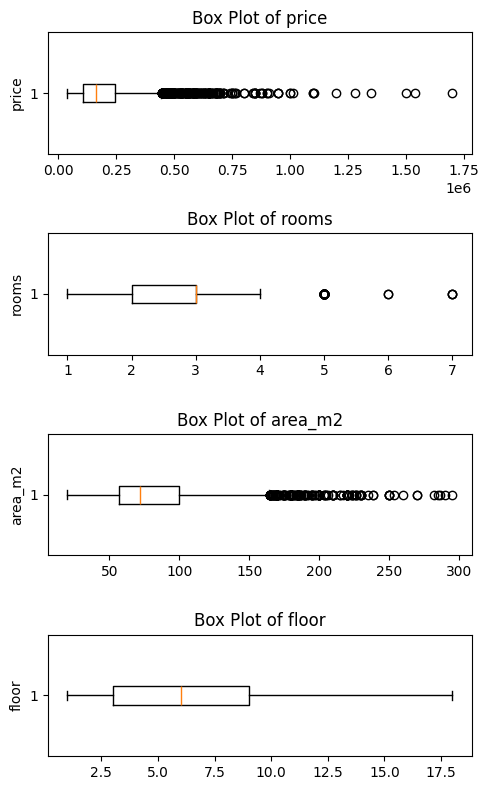

In [260]:
plot_numeric_distributions(df_clean_2, key_numeric_features)

In [261]:
address_series = df_clean_2["address"].fillna("").str.strip()

result_houses = df_clean_2[
    address_series.str.lower().str.startswith("bakı")
    & address_series.str.contains(r"a[ğg],|sahil|may|i[cç]əri[şs]əhər|nəriman|yasamal|emlər|gənclik|nizami", case=False, regex=True, na=False)
    & (df_clean_2['price_per_m2'] < 1000)
]

print("Matching houses:", result_houses.shape[0])
result_houses

Matching houses: 4


,price,rooms,area_m2,floor,has_document,address,avtodayanacaq,balkon,duzelme,esyali,hovuz,internet,isiq,kabel_tv,kombi,kondisioner,lift,merkezi_qizdirici_sistem,metbex_mebeli,pvc_pencere,qaz,su,telefon,temirli,price_per_m2,rooms_group,rooms_group_code
1096,67000,2.0,72.56,5.0,Yes,"Bakı, Yasamal, metro Elmlər akademiyası",No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,923.373760,1-2,1
1414,60284,2.0,62.60,16.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,963.003195,1-2,1
2889,52200,3.0,53.00,2.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,No,Yes,Yes,Yes,Yes,No,Yes,984.905660,3-4,2
2935,60743,2.0,63.00,16.0,Yes,"Bakı, Yasamal, Yasamal qəs.",Yes,No,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,Yes,Yes,No,Yes,964.174603,1-2,1


## Summarize Cleaning Results and Export Final Dataset
Report final data quality metrics and save the cleaned apartment dataset for downstream modeling.

In [262]:
df_clean_2 = df_clean_2.drop(columns=['price_per_m2'], errors="ignore")

In [263]:
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean_2.shape}")
# - Number of rows removed
print(f"Number of rows removed: {df.shape[0] - df_clean_2.shape[0]}")
# - Number of columns removed
print(f"Number of columns removed: {df.shape[1] - df_clean_2.shape[1]}")
# - Remaining missing values count
print(f"Remaining missing values count: {df_clean_2.isnull().sum().sum()}")
# - Data types value counts
print("Data types value counts:")
print(df_clean_2.dtypes.value_counts())

Original dataset shape: (4987, 24)
Cleaned dataset shape: (4273, 26)
Number of rows removed: 714
Number of columns removed: -2
Remaining missing values count: 0
Data types value counts:
object      20
float64      3
int64        2
category     1
Name: count, dtype: int64


In [264]:
df_clean_2.to_csv('../../data/apartment/satilir_properties_apartment_cleaned.csv', index=False)
print("Cleaned dataset saved to 'data/apartment/satilir_properties_apartment_cleaned.csv'")

Cleaned dataset saved to 'data/apartment/satilir_properties_apartment_cleaned.csv'
